# Volume Climax Pullback V3 Client Notebook - M2K

Ce notebook client gele par defaut la spec V3 retenue pour **M2K** :

- **Spec recommandee par defaut** : `dynamic_exit_atr_target_1p0_ts4_vq0p95_bf0p5_ra1p2`
- **Reference V2 explicite** : `dynamic_exit_atr_target_1p0_ts3_vq0p95_bf0p5_ra1p2`
- **Benchmark de marche** : buy & hold daily close-to-close sur le meme sous-jacent RTH 1h


Philosophie du notebook :

- il relit la campagne V3 auditee,
- il laisse les parametres de la spec modifiables dans le premier bloc,
- il recharge seulement les specs de comparaison utiles,
- il montre des heatmaps compactes de robustesse sans relancer une recherche large.


In [1]:
import json
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent

if not (ROOT / "pyproject.toml").exists():
    raise RuntimeError("Impossible de retrouver la racine du repo depuis le notebook.")

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

from src.analytics.orb_notebook_utils import (
    build_scope_readout_markdown,
    curve_annualized_return,
    curve_daily_sharpe,
    curve_daily_vol,
    curve_max_drawdown_pct,
    curve_total_return_pct,
    format_curve_stats_line,
)
from src.analytics.volume_climax_pullback_notebook_utils import (
    core_label,
    evaluate_variant,
    exit_profile_label,
    find_variant_row,
    regime_signature,
    variant_from_summary_row,
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)
sns.set_theme(style="whitegrid")


def fmt_money(value: float | int | None) -> str:
    if value is None or pd.isna(value):
        return "n/a"
    return f"{float(value):,.1f} USD"


def fmt_float(value: float | int | None, digits: int = 3) -> str:
    if value is None or pd.isna(value):
        return "n/a"
    return f"{float(value):.{digits}f}"


def fmt_pct(value: float | int | None, digits: int = 1) -> str:
    if value is None or pd.isna(value):
        return "n/a"
    return f"{float(value):.{digits}f}%"


def scope_lookup(frame: pd.DataFrame) -> pd.DataFrame:
    return frame.set_index("scope")


def rounded_view(frame: pd.DataFrame, digits: int = 3) -> pd.DataFrame:
    out = frame.copy()
    numeric_cols = out.select_dtypes(include=["number"]).columns
    out[numeric_cols] = out[numeric_cols].round(digits)
    return out


def curve_stats_line(name: str, curve: pd.DataFrame, metrics_row: pd.Series | None = None) -> str:
    return format_curve_stats_line(
        name=name,
        sharpe=curve_daily_sharpe(curve),
        ret_pct=curve_total_return_pct(curve, INITIAL_CAPITAL_USD),
        cagr_pct=curve_annualized_return(curve, INITIAL_CAPITAL_USD) * 100.0,
        vol_pct=curve_daily_vol(curve) * 100.0,
        dd_pct=abs(curve_max_drawdown_pct(curve)),
        pf=None if metrics_row is None else float(metrics_row.get("profit_factor", 0.0)),
        exp=None if metrics_row is None else float(metrics_row.get("expectancy", 0.0)),
    )


def metrics_snapshot(bundle: dict, label: str) -> dict:
    metrics = scope_lookup(bundle["metrics_by_scope"])
    overall = metrics.loc["overall"]
    oos = metrics.loc["oos"]
    return {
        "label": label,
        "overall_net_pnl": round(float(overall["net_pnl"]), 1),
        "overall_sharpe": round(float(overall["sharpe"]), 3),
        "overall_profit_factor": round(float(overall["profit_factor"]), 3),
        "overall_expectancy": round(float(overall["expectancy"]), 2),
        "overall_trades": int(overall["nb_trades"]),
        "oos_net_pnl": round(float(oos["net_pnl"]), 1),
        "oos_sharpe": round(float(oos["sharpe"]), 3),
        "oos_profit_factor": round(float(oos["profit_factor"]), 3),
        "oos_expectancy": round(float(oos["expectancy"]), 2),
        "oos_trades": int(oos["nb_trades"]),
    }


In [2]:
EXPORT_ROOT = ROOT / r"data\exports\volume_climax_pullback_v3_run\volume_climax_pullback_v3_20260402_184702"
V2_REFERENCE_ROOT = ROOT / r"data\exports\volume_climax_pullback_v2_run\volume_climax_pullback_v2_20260401_214553"
SYMBOL = "M2K"
INITIAL_CAPITAL_USD = 50_000.0

FROZEN_VARIANT_NAME = "dynamic_exit_atr_target_1p0_ts4_vq0p95_bf0p5_ra1p2"
FROZEN_V2_REFERENCE_VARIANT_NAME = "dynamic_exit_atr_target_1p0_ts3_vq0p95_bf0p5_ra1p2"
FROZEN_V3_DYNAMIC_COMPARE_NAME = None
FROZEN_V3_DYNAMIC_COMPARE_LABEL = None

# Leave ACTIVE_VARIANT_NAME to None to resolve the active spec from the explicit knobs below.
ACTIVE_VARIANT_NAME = None
ACTIVE_FAMILY = "dynamic_exit"
ACTIVE_EXIT_MODE = "atr_fraction"
ACTIVE_TIME_STOP_BARS = 4
ACTIVE_VOLUME_QUANTILE = 0.95
ACTIVE_BODY_FRACTION = 0.5
ACTIVE_RANGE_ATR = 1.2
ACTIVE_EMA_SLOPE_FILTER = "off"
ACTIVE_ATR_PERCENTILE_BAND = "off"
ACTIVE_COMPRESSION_FILTER = "off"

COMPARE_TO_V2_REFERENCE = True
COMPARE_TO_BUY_HOLD = True
SHOW_TOP_COMPETITORS = 10
REGIME_HEATMAP_CORE = "vq0.950 | bf0.5 | ra1.2"

required_paths = {
    "export_root": EXPORT_ROOT,
    "run_metadata": EXPORT_ROOT / "run_metadata.json",
    "final_verdict": EXPORT_ROOT / "final_verdict.json",
    "summary_variants": EXPORT_ROOT / "summary_variants.csv",
    "ranking_oos_by_asset": EXPORT_ROOT / "ranking_oos_by_asset.csv",
    "v2_reference_root": V2_REFERENCE_ROOT,
    "v2_summary_variants": V2_REFERENCE_ROOT / "summary_variants.csv",
}

missing = [name for name, path in required_paths.items() if not path.exists()]
if missing:
    raise FileNotFoundError(f"Fichiers manquants pour le notebook: {missing}")

print("EXPORT_ROOT =", EXPORT_ROOT)
print("SYMBOL =", SYMBOL)
print("FROZEN_VARIANT_NAME =", FROZEN_VARIANT_NAME)
print("ACTIVE_VARIANT_NAME =", ACTIVE_VARIANT_NAME)


EXPORT_ROOT = C:\Donnees\Business\Trading\Code\algo-trading-intraday-research\data\exports\volume_climax_pullback_v3_run\volume_climax_pullback_v3_20260402_184702
SYMBOL = M2K
FROZEN_VARIANT_NAME = dynamic_exit_atr_target_1p0_ts4_vq0p95_bf0p5_ra1p2
ACTIVE_VARIANT_NAME = None


In [3]:
run_metadata = json.loads((EXPORT_ROOT / "run_metadata.json").read_text(encoding="utf-8"))
final_verdict = json.loads((EXPORT_ROOT / "final_verdict.json").read_text(encoding="utf-8"))

summary = pd.read_csv(EXPORT_ROOT / "summary_variants.csv")
ranking_by_asset = pd.read_csv(EXPORT_ROOT / "ranking_oos_by_asset.csv")
v2_summary = pd.read_csv(V2_REFERENCE_ROOT / "summary_variants.csv")

asset_summary = summary.loc[summary["symbol"] == SYMBOL].copy().reset_index(drop=True)
asset_ranking = ranking_by_asset.loc[ranking_by_asset["symbol"] == SYMBOL].copy().reset_index(drop=True)
frozen_row = asset_summary.loc[asset_summary["variant_name"] == FROZEN_VARIANT_NAME].iloc[0]

active_row = find_variant_row(
    asset_summary,
    symbol=SYMBOL,
    family=ACTIVE_FAMILY,
    exit_mode=ACTIVE_EXIT_MODE,
    time_stop_bars=ACTIVE_TIME_STOP_BARS,
    volume_quantile=ACTIVE_VOLUME_QUANTILE,
    min_body_fraction=ACTIVE_BODY_FRACTION,
    min_range_atr=ACTIVE_RANGE_ATR,
    ema_slope_filter=ACTIVE_EMA_SLOPE_FILTER,
    atr_percentile_band=ACTIVE_ATR_PERCENTILE_BAND,
    compression_filter=ACTIVE_COMPRESSION_FILTER,
    variant_name=ACTIVE_VARIANT_NAME,
)
active_variant_changed = str(active_row["variant_name"]) != FROZEN_VARIANT_NAME

v2_reference_row = v2_summary.loc[
    (v2_summary["symbol"] == SYMBOL)
    & (v2_summary["variant_name"] == FROZEN_V2_REFERENCE_VARIANT_NAME)
].iloc[0]

dynamic_compare_row = None
if FROZEN_V3_DYNAMIC_COMPARE_NAME is not None:
    dynamic_compare_row = asset_summary.loc[asset_summary["variant_name"] == FROZEN_V3_DYNAMIC_COMPARE_NAME].iloc[0]

top_competitors = asset_ranking.head(SHOW_TOP_COMPETITORS).copy()
top_competitors["core_label"] = top_competitors.apply(core_label, axis=1)
top_competitors["regime_signature"] = top_competitors.apply(regime_signature, axis=1)

active_bundle = evaluate_variant(
    symbol=SYMBOL,
    variant=variant_from_summary_row(active_row),
    initial_capital=INITIAL_CAPITAL_USD,
)
v2_reference_bundle = evaluate_variant(
    symbol=SYMBOL,
    variant=variant_from_summary_row(v2_reference_row),
    initial_capital=INITIAL_CAPITAL_USD,
)
dynamic_compare_bundle = None
if dynamic_compare_row is not None:
    dynamic_compare_bundle = evaluate_variant(
        symbol=SYMBOL,
        variant=variant_from_summary_row(dynamic_compare_row),
        initial_capital=INITIAL_CAPITAL_USD,
    )

active_metrics = scope_lookup(active_bundle["metrics_by_scope"])
v2_reference_metrics = scope_lookup(v2_reference_bundle["metrics_by_scope"])
dynamic_compare_metrics = None if dynamic_compare_bundle is None else scope_lookup(dynamic_compare_bundle["metrics_by_scope"])

oos_start_date = pd.to_datetime(active_bundle["oos_sessions"][0]) if active_bundle["oos_sessions"] else None
asset_verdict = final_verdict["verdict_by_symbol"][SYMBOL]["verdict"]

display(Markdown(f"**Asset verdict from V3 export:** `{asset_verdict}`"))
if active_variant_changed:
    display(Markdown(f"**Notebook override active:** `{active_row['variant_name']}` instead of frozen `{FROZEN_VARIANT_NAME}`."))


**Asset verdict from V3 export:** `recommandee`

## 1. Lecture rapide

On veut repondre vite a quatre questions:

1. la spec gelee tient-elle toujours une fois rejouee seule?
2. gagne-t-elle encore face a la reference V2 retenue?
3. que dit le benchmark buy & hold sur la periode complete?
4. le paysage de variants reste-t-il lisible sans concurrence excessive?


In [4]:
quick_lines = [
    "### Synthese executive",
    f"- Spec gelee: `{FROZEN_VARIANT_NAME}`.",
    f"- Spec actuellement chargee: `{active_row['variant_name']}`.",
    f"- Reference V2: `{FROZEN_V2_REFERENCE_VARIANT_NAME}`.",
    f"- OOS active: Sharpe **{fmt_float(active_metrics.loc['oos', 'sharpe'])}** | PF **{fmt_float(active_metrics.loc['oos', 'profit_factor'])}** | Net PnL **{fmt_money(active_metrics.loc['oos', 'net_pnl'])}** | Trades **{int(active_metrics.loc['oos', 'nb_trades'])}**.",
    f"- Delta OOS vs V2: Sharpe **{fmt_float(active_metrics.loc['oos', 'sharpe'] - v2_reference_metrics.loc['oos', 'sharpe'])}** | Net PnL **{fmt_money(active_metrics.loc['oos', 'net_pnl'] - v2_reference_metrics.loc['oos', 'net_pnl'])}**.",
    f"- Buy & hold full sample: **{fmt_pct(curve_total_return_pct(active_bundle['benchmark_curve_full'], INITIAL_CAPITAL_USD))}** de retour avec **{fmt_pct(abs(curve_max_drawdown_pct(active_bundle['benchmark_curve_full'])))}** de max drawdown.",
    f"- Nombre de concurrents affiches dans le notebook: **{len(top_competitors)}**.",
]

display(Markdown("\n".join([line for line in quick_lines if line])))


### Synthese executive
- Spec gelee: `dynamic_exit_atr_target_1p0_ts4_vq0p95_bf0p5_ra1p2`.
- Spec actuellement chargee: `dynamic_exit_atr_target_1p0_ts4_vq0p95_bf0p5_ra1p2`.
- Reference V2: `dynamic_exit_atr_target_1p0_ts3_vq0p95_bf0p5_ra1p2`.
- OOS active: Sharpe **1.567** | PF **1.801** | Net PnL **986.7 USD** | Trades **99**.
- Delta OOS vs V2: Sharpe **0.052** | Net PnL **30.0 USD**.
- Buy & hold full sample: **54.2%** de retour avec **42.1%** de max drawdown.
- Nombre de concurrents affiches dans le notebook: **10**.

## 2. Parametres exacts et modifiables

Le bloc precedent fixe un notebook client, pas une recherche ouverte.

- `FROZEN_*` documente la version recommandee du run V3.
- `ACTIVE_*` permet de permuter proprement a un autre variant **de la meme grille V3 exportee**.
- si `ACTIVE_VARIANT_NAME` reste `None`, le notebook reconstruit le variant a partir des parametres explicites.


In [5]:
parameter_snapshot = pd.DataFrame(
    [
        {"parameter": "SYMBOL", "value": SYMBOL},
        {"parameter": "INITIAL_CAPITAL_USD", "value": INITIAL_CAPITAL_USD},
        {"parameter": "FROZEN_VARIANT_NAME", "value": FROZEN_VARIANT_NAME},
        {"parameter": "ACTIVE_VARIANT_NAME", "value": ACTIVE_VARIANT_NAME},
        {"parameter": "ACTIVE_FAMILY", "value": ACTIVE_FAMILY},
        {"parameter": "ACTIVE_EXIT_MODE", "value": ACTIVE_EXIT_MODE},
        {"parameter": "ACTIVE_TIME_STOP_BARS", "value": ACTIVE_TIME_STOP_BARS},
        {"parameter": "ACTIVE_VOLUME_QUANTILE", "value": ACTIVE_VOLUME_QUANTILE},
        {"parameter": "ACTIVE_BODY_FRACTION", "value": ACTIVE_BODY_FRACTION},
        {"parameter": "ACTIVE_RANGE_ATR", "value": ACTIVE_RANGE_ATR},
        {"parameter": "ACTIVE_EMA_SLOPE_FILTER", "value": ACTIVE_EMA_SLOPE_FILTER},
        {"parameter": "ACTIVE_ATR_PERCENTILE_BAND", "value": ACTIVE_ATR_PERCENTILE_BAND},
        {"parameter": "ACTIVE_COMPRESSION_FILTER", "value": ACTIVE_COMPRESSION_FILTER},
        {"parameter": "REGIME_HEATMAP_CORE", "value": REGIME_HEATMAP_CORE},
    ]
)

active_parameter_table = pd.DataFrame(
    [
        {"field": "variant_name", "active": active_row["variant_name"], "frozen_default": frozen_row["variant_name"]},
        {"field": "family", "active": active_row["family"], "frozen_default": frozen_row["family"]},
        {"field": "exit_mode", "active": active_row["exit_mode"], "frozen_default": frozen_row["exit_mode"]},
        {"field": "time_stop_bars", "active": int(active_row["time_stop_bars"]), "frozen_default": int(frozen_row["time_stop_bars"])},
        {"field": "volume_quantile", "active": float(active_row["volume_quantile"]), "frozen_default": float(frozen_row["volume_quantile"])},
        {"field": "min_body_fraction", "active": float(active_row["min_body_fraction"]), "frozen_default": float(frozen_row["min_body_fraction"])},
        {"field": "min_range_atr", "active": float(active_row["min_range_atr"]), "frozen_default": float(frozen_row["min_range_atr"])},
        {"field": "ema_slope_filter", "active": active_row.get("ema_slope_filter", "off"), "frozen_default": frozen_row.get("ema_slope_filter", "off")},
        {"field": "atr_percentile_band", "active": active_row.get("atr_percentile_band", "off"), "frozen_default": frozen_row.get("atr_percentile_band", "off")},
        {"field": "compression_filter", "active": active_row.get("compression_filter", "off"), "frozen_default": frozen_row.get("compression_filter", "off")},
    ]
)

reference_parameter_table = pd.DataFrame(
    [
        {"field": "variant_name", "v2_reference": v2_reference_row["variant_name"]},
        {"field": "family", "v2_reference": v2_reference_row["family"]},
        {"field": "exit_mode", "v2_reference": v2_reference_row["exit_mode"]},
        {"field": "time_stop_bars", "v2_reference": int(v2_reference_row["time_stop_bars"])},
        {"field": "volume_quantile", "v2_reference": float(v2_reference_row["volume_quantile"])},
        {"field": "min_body_fraction", "v2_reference": float(v2_reference_row["min_body_fraction"])},
        {"field": "min_range_atr", "v2_reference": float(v2_reference_row["min_range_atr"])},
        {"field": "ema_slope_filter", "v2_reference": v2_reference_row.get("ema_slope_filter", "off")},
        {"field": "atr_percentile_band", "v2_reference": v2_reference_row.get("atr_percentile_band", "off")},
        {"field": "compression_filter", "v2_reference": v2_reference_row.get("compression_filter", "off")},
    ]
)

display(Markdown("### Parametres editables du notebook"))
display(parameter_snapshot)

display(Markdown("### Spec active vs spec gelee"))
display(active_parameter_table)

display(Markdown("### Reference V2 rechargee dans le notebook"))
display(reference_parameter_table)


### Parametres editables du notebook

,parameter,value
0,SYMBOL,M2K
1,INITIAL_CAPITAL_USD,50000.0
2,FROZEN_VARIANT_NAME,dynamic_exit_atr_target_1p0_ts4_vq0p95_bf0p5_r...
3,ACTIVE_VARIANT_NAME,None
4,ACTIVE_FAMILY,dynamic_exit
5,ACTIVE_EXIT_MODE,atr_fraction
6,ACTIVE_TIME_STOP_BARS,4
7,ACTIVE_VOLUME_QUANTILE,0.95
8,ACTIVE_BODY_FRACTION,0.5
9,ACTIVE_RANGE_ATR,1.2


### Spec active vs spec gelee

,field,active,frozen_default
0,variant_name,dynamic_exit_atr_target_1p0_ts4_vq0p95_bf0p5_r...,dynamic_exit_atr_target_1p0_ts4_vq0p95_bf0p5_r...
1,family,dynamic_exit,dynamic_exit
2,exit_mode,atr_fraction,atr_fraction
3,time_stop_bars,4,4
4,volume_quantile,0.95,0.95
5,min_body_fraction,0.5,0.5
6,min_range_atr,1.2,1.2
7,ema_slope_filter,off,off
8,atr_percentile_band,off,off
9,compression_filter,off,off


### Reference V2 rechargee dans le notebook

,field,v2_reference
0,variant_name,dynamic_exit_atr_target_1p0_ts3_vq0p95_bf0p5_r...
1,family,dynamic_exit
2,exit_mode,atr_fraction
3,time_stop_bars,3
4,volume_quantile,0.95
5,min_body_fraction,0.5
6,min_range_atr,1.2
7,ema_slope_filter,off
8,atr_percentile_band,off
9,compression_filter,off


## 3. Snapshot recherche et references

Cette section ne refait pas le classement V3. Elle le remet en forme pour un lecteur client:

- meilleur candidat actif,
- concurrents directs,
- reference V2 rechargee dans le notebook,
- optionnellement meilleur `dynamic_exit` pur pour MGC.


In [6]:
bundle_snapshot = pd.DataFrame(
    [
        metrics_snapshot(active_bundle, "active_v3"),
        metrics_snapshot(v2_reference_bundle, "v2_reference"),
    ]
)
display(Markdown("### Replay snapshot"))
display(bundle_snapshot)



display(Markdown("### Top competitors from the audited V3 ranking"))
display(
    rounded_view(
        top_competitors[
            [
                "variant_name",
                "family",
                "exit_mode",
                "time_stop_bars",
                "core_label",
                "regime_signature",
                "oos_sharpe",
                "oos_profit_factor",
                "oos_net_pnl",
                "oos_nb_trades",
                "variant_status",
                "selection_score",
            ]
        ]
    )
)


### Replay snapshot

,label,overall_net_pnl,overall_sharpe,overall_profit_factor,overall_expectancy,overall_trades,oos_net_pnl,oos_sharpe,oos_profit_factor,oos_expectancy,oos_trades
0,active_v3,1460.7,0.721,1.298,4.3,340,986.7,1.567,1.801,9.97,99
1,v2_reference,1393.2,0.688,1.282,4.1,340,956.7,1.515,1.763,9.66,99


### Top competitors from the audited V3 ranking

,variant_name,family,exit_mode,time_stop_bars,core_label,regime_signature,oos_sharpe,oos_profit_factor,oos_net_pnl,oos_nb_trades,variant_status,selection_score
0,dynamic_exit_atr_target_1p0_ts4_vq0p95_bf0p5_r...,dynamic_exit,atr_fraction,4,vq0.950 | bf0.5 | ra1.2,off / off / off,1.567,1.801,986.650,99,survivor,2.131
1,dynamic_exit_atr_target_1p0_ts3_vq0p95_bf0p5_r...,dynamic_exit,atr_fraction,3,vq0.950 | bf0.5 | ra1.2,off / off / off,1.515,1.763,956.650,99,survivor,2.066
2,dynamic_exit_atr_target_1p0_ts4_vq0p95_bf0p6_r...,dynamic_exit,atr_fraction,4,vq0.950 | bf0.6 | ra1.2,off / off / off,1.416,1.836,771.600,80,survivor,1.899
3,dynamic_exit_atr_target_1p0_ts2_vq0p95_bf0p5_r...,dynamic_exit,atr_fraction,2,vq0.950 | bf0.5 | ra1.2,off / off / off,1.353,1.657,835.825,99,survivor,1.840
4,dynamic_exit_atr_target_1p0_ts3_vq0p95_bf0p6_r...,dynamic_exit,atr_fraction,3,vq0.950 | bf0.6 | ra1.2,off / off / off,1.356,1.785,741.600,80,survivor,1.820
5,dynamic_exit_atr_target_1p0_ts3_vq0p975_bf0p6_...,dynamic_exit,atr_fraction,3,vq0.975 | bf0.6 | ra1.2,off / off / off,1.253,1.833,630.900,63,survivor,1.719
6,dynamic_exit_atr_target_1p0_ts4_vq0p95_bf0p5_r...,dynamic_exit,atr_fraction,4,vq0.950 | bf0.5 | ra1.5,off / off / off,1.249,1.621,730.100,92,survivor,1.688
7,dynamic_exit_atr_target_1p0_ts4_vq0p975_bf0p6_...,dynamic_exit,atr_fraction,4,vq0.975 | bf0.6 | ra1.2,off / off / off,1.227,1.812,615.400,63,survivor,1.686
8,dynamic_exit_atr_target_1p0_ts3_vq0p95_bf0p5_r...,dynamic_exit,atr_fraction,3,vq0.950 | bf0.5 | ra1.5,off / off / off,1.194,1.584,700.100,92,survivor,1.617
9,dynamic_exit_atr_target_1p0_ts2_vq0p95_bf0p6_r...,dynamic_exit,atr_fraction,2,vq0.950 | bf0.6 | ra1.2,off / off / off,1.188,1.660,635.800,80,survivor,1.596


## 4. Courbes, drawdown et benchmark

Lecture attendue:

- la courbe active doit rester lisible vs reference V2,
- l OOS only sert a verifier que le signal ne tient pas seulement par l IS,
- le benchmark buy & hold sert de repere de marche, pas de baseline metier.


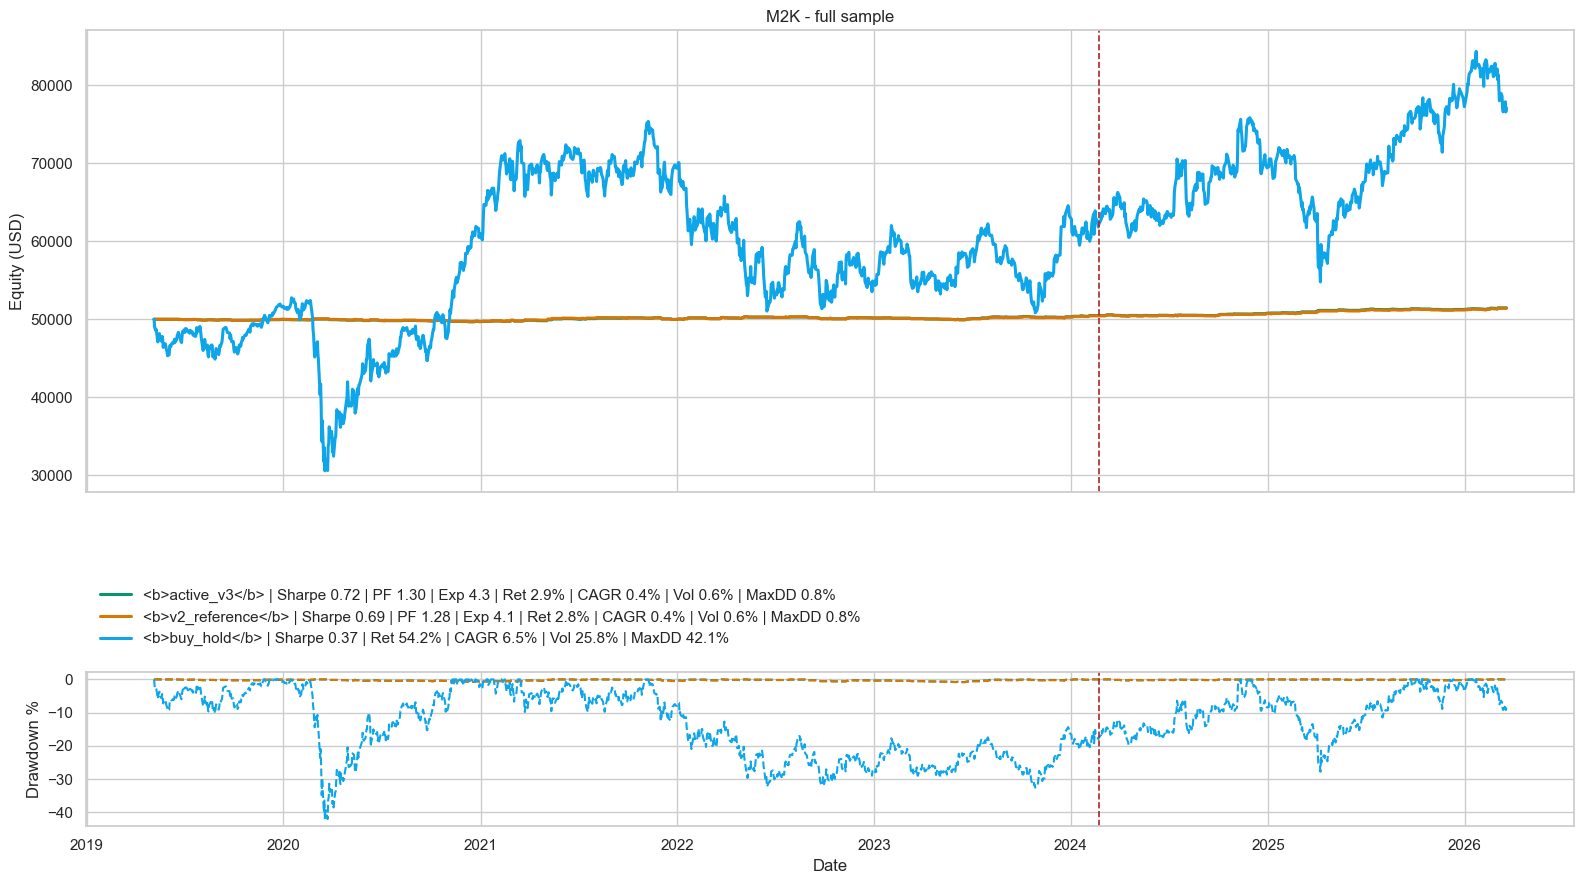

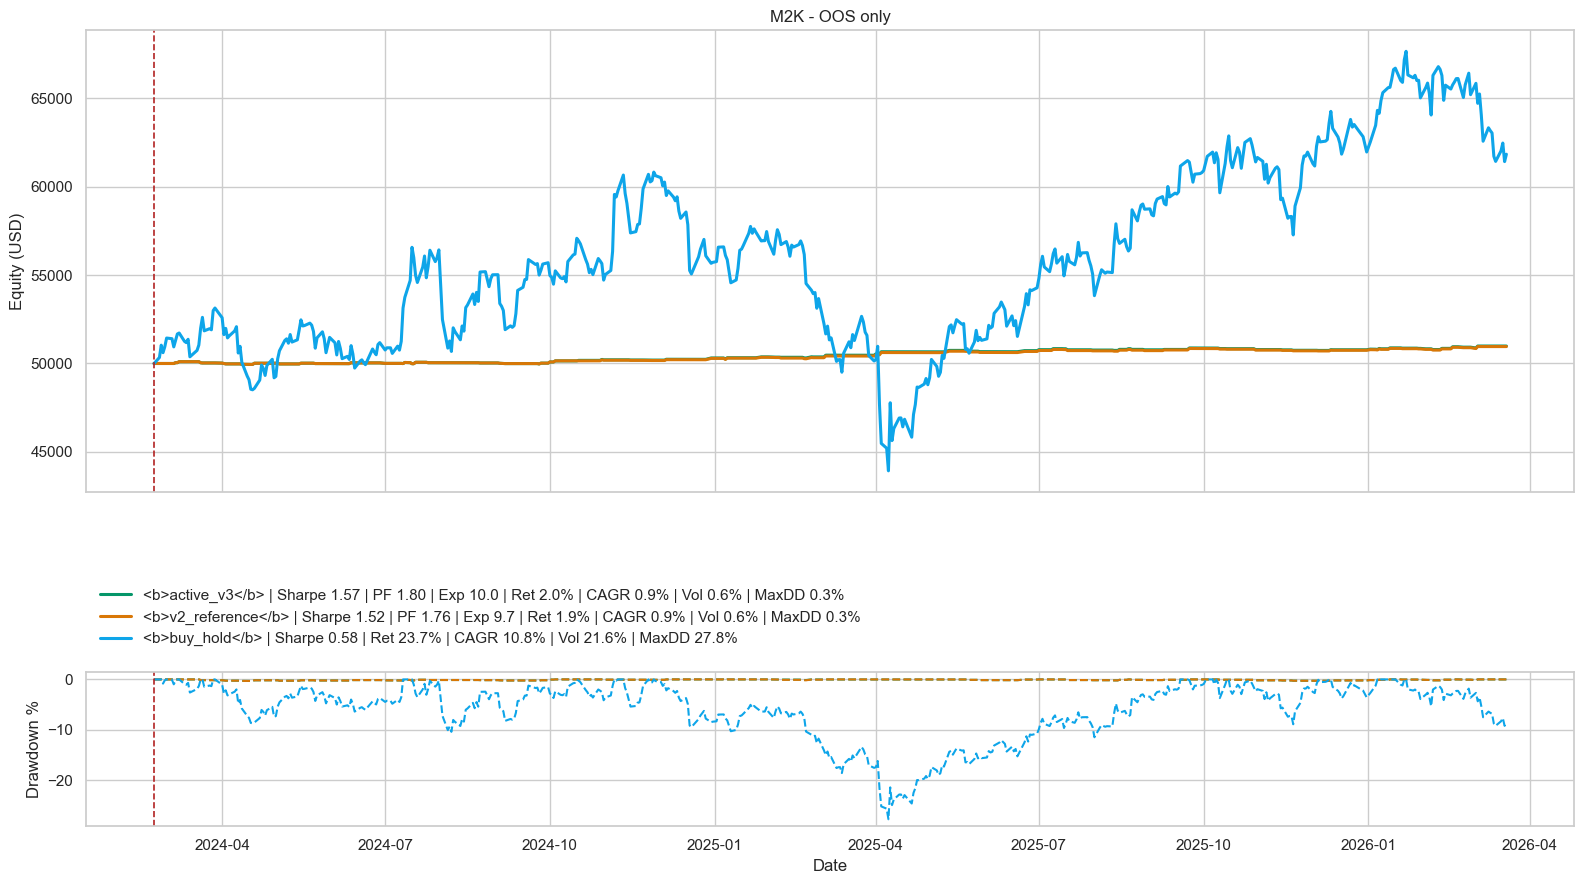

### Scope check
- **Active full-sample curve** includes every selected trade across IS and OOS. Final equity: **51,461 USD** | Return: **2.9%** | MaxDD: **-0.8%**.
- **Active OOS-only curve** keeps only the OOS trades. Final equity: **50,987 USD** | Return: **2.0%** | MaxDD: **-0.3%**.
- Read `overall_*` metrics against the full-sample curve and `oos_*` metrics against the OOS-only curve.

In [7]:
full_traces = [
    {
        "name": "active_v3",
        "curve": active_bundle["curve_full"],
        "metrics_row": active_metrics.loc["overall"],
        "color": "#059669",
    },
    {
        "name": "v2_reference",
        "curve": v2_reference_bundle["curve_full"],
        "metrics_row": v2_reference_metrics.loc["overall"],
        "color": "#d97706",
    },
]
oos_traces = [
    {
        "name": "active_v3",
        "curve": active_bundle["curve_oos"],
        "metrics_row": active_metrics.loc["oos"],
        "color": "#059669",
    },
    {
        "name": "v2_reference",
        "curve": v2_reference_bundle["curve_oos"],
        "metrics_row": v2_reference_metrics.loc["oos"],
        "color": "#d97706",
    },
]


if COMPARE_TO_BUY_HOLD:
    full_traces.append(
        {
            "name": "buy_hold",
            "curve": active_bundle["benchmark_curve_full"],
            "metrics_row": None,
            "color": "#0ea5e9",
        }
    )
    oos_traces.append(
        {
            "name": "buy_hold",
            "curve": active_bundle["benchmark_curve_oos"],
            "metrics_row": None,
        "color": "#0ea5e9",
        }
    )

vline_x = None if oos_start_date is None else pd.to_datetime(oos_start_date).to_pydatetime()

def build_curve_figure(title: str, traces: list[dict]) -> None:
    fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
    for trace in traces:
        axes[0].plot(
            trace["curve"]["timestamp"],
            trace["curve"]["equity"],
            label=curve_stats_line(trace["name"], trace["curve"], trace["metrics_row"]),
            linewidth=2.2,
            color=trace["color"],
        )
        axes[1].plot(
            trace["curve"]["timestamp"],
            trace["curve"]["drawdown_pct"],
            linewidth=1.5,
            linestyle="--",
            color=trace["color"],
        )
    if vline_x is not None:
        axes[0].axvline(vline_x, linestyle="--", color="firebrick", linewidth=1.2)
        axes[1].axvline(vline_x, linestyle="--", color="firebrick", linewidth=1.2)
    axes[0].set_title(title)
    axes[0].set_ylabel("Equity (USD)")
    axes[1].set_ylabel("Drawdown %")
    axes[1].set_xlabel("Date")
    axes[0].legend(loc="upper left", bbox_to_anchor=(0.0, -0.18), frameon=False)
    plt.tight_layout()
    plt.show()

build_curve_figure(f"{SYMBOL} - full sample", full_traces)
build_curve_figure(f"{SYMBOL} - OOS only", oos_traces)

display(Markdown(build_scope_readout_markdown(
    full_curve=active_bundle["curve_full"],
    oos_curve=active_bundle["curve_oos"],
    initial_capital=INITIAL_CAPITAL_USD,
    full_label="Active full-sample curve",
    oos_label="Active OOS-only curve",
)))


## 5. Heatmaps de robustesse

Les heatmaps ne sont pas une nouvelle optimisation. Elles servent a verifier que la spec gelee est placee dans un voisinage credible.

- pour tous les actifs: heatmaps `dynamic_exit` sur la grille compacte V3,
- pour MGC: heatmaps de branche `regime_filtered` autour du core choisi.


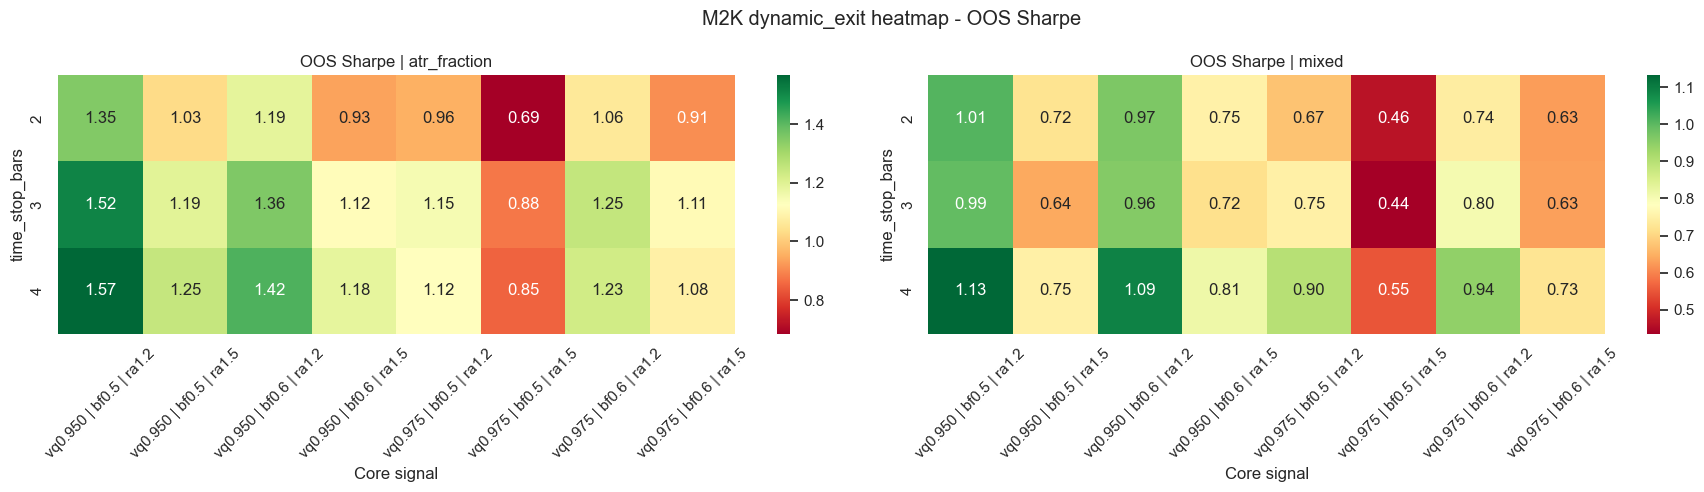

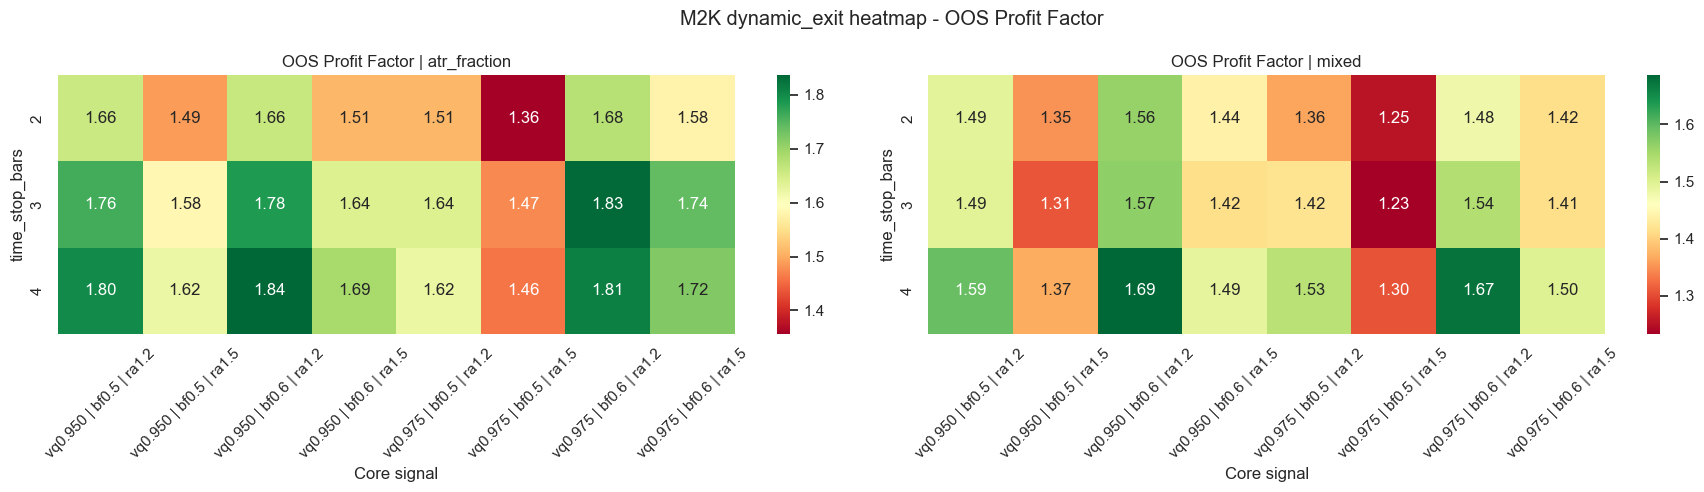

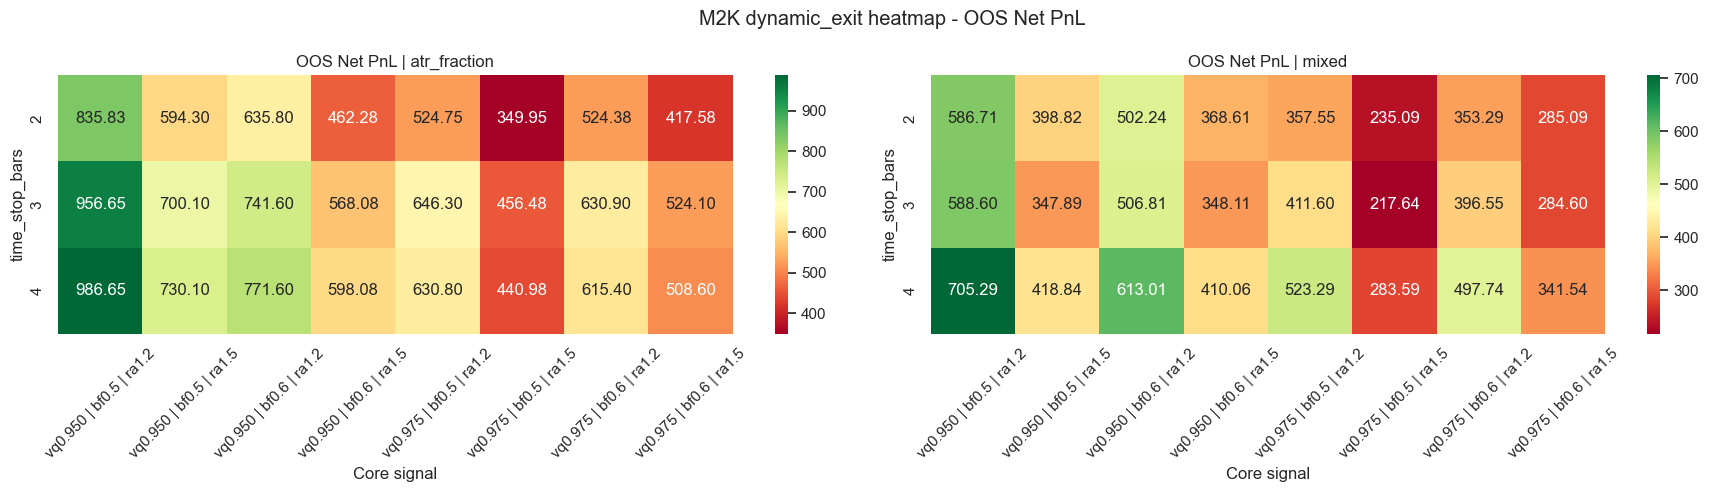

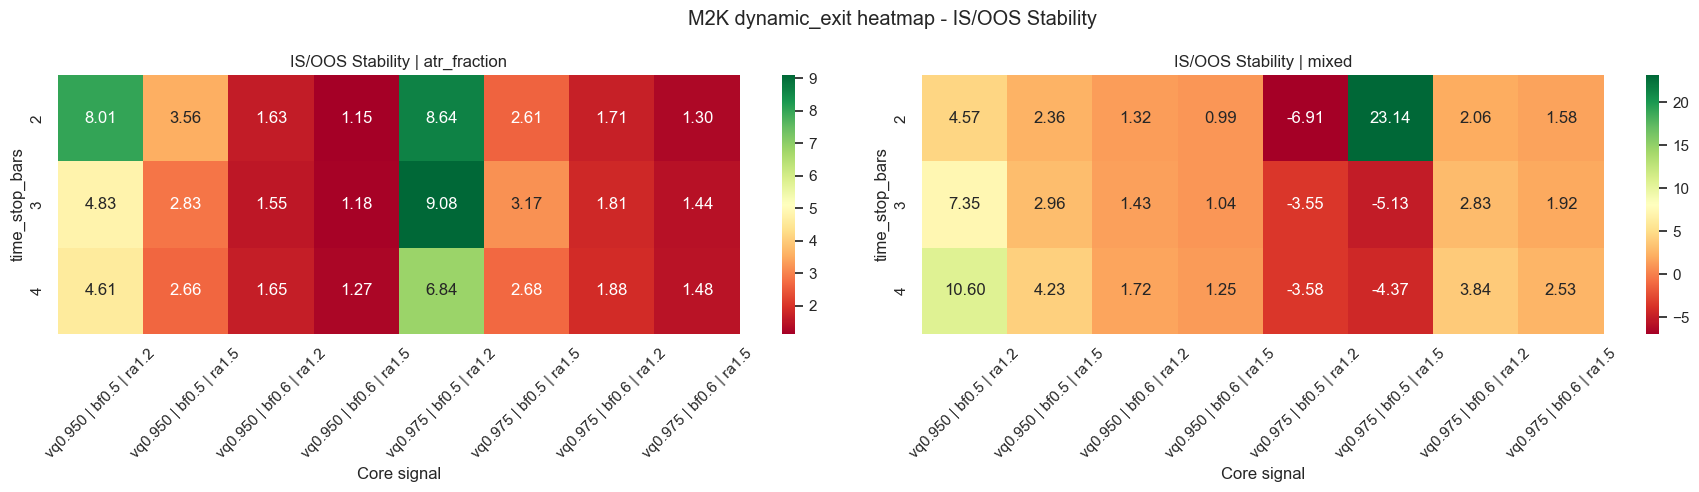

In [8]:
dynamic_src = asset_summary.loc[asset_summary["family"] == "dynamic_exit"].copy()
dynamic_src["core_label"] = dynamic_src.apply(core_label, axis=1)
dynamic_src["exit_profile"] = dynamic_src.apply(exit_profile_label, axis=1)

core_order = (
    dynamic_src[["core_label", "volume_quantile", "min_body_fraction", "min_range_atr"]]
    .drop_duplicates()
    .sort_values(["volume_quantile", "min_body_fraction", "min_range_atr"])
    ["core_label"]
    .tolist()
)
exit_mode_order = ["atr_fraction", "mixed"]
metric_specs = [
    ("oos_sharpe", "OOS Sharpe", "RdYlGn"),
    ("oos_profit_factor", "OOS Profit Factor", "RdYlGn"),
    ("oos_net_pnl", "OOS Net PnL", "RdYlGn"),
    ("stability_is_oos_sharpe_ratio", "IS/OOS Stability", "RdYlGn"),
]

for metric, title, scale in metric_specs:
    fig, axes = plt.subplots(1, len(exit_mode_order), figsize=(18, 5), squeeze=False)
    for col_index, exit_mode in enumerate(exit_mode_order):
        pivot = (
            dynamic_src.loc[dynamic_src["exit_mode"] == exit_mode]
            .pivot_table(index="time_stop_bars", columns="core_label", values=metric, aggfunc="mean")
            .reindex(index=sorted(dynamic_src["time_stop_bars"].unique()), columns=core_order)
        )
        sns.heatmap(
            pivot,
            ax=axes[0, col_index],
            cmap=scale,
            annot=True,
            fmt=".2f",
            cbar=True,
        )
        axes[0, col_index].set_title(f"{title} | {exit_mode}")
        axes[0, col_index].set_xlabel("Core signal")
        axes[0, col_index].set_ylabel("time_stop_bars")
        axes[0, col_index].tick_params(axis="x", rotation=45)
    fig.suptitle(f"{SYMBOL} dynamic_exit heatmap - {title}")
    plt.tight_layout()
    plt.show()

regime_src = asset_summary.loc[asset_summary["family"] == "regime_filtered"].copy()
if not regime_src.empty:
    regime_src["core_label"] = regime_src.apply(core_label, axis=1)
    regime_src["regime_signature"] = regime_src.apply(regime_signature, axis=1)
    regime_src["exit_profile"] = regime_src.apply(exit_profile_label, axis=1)
    scoped_regime = regime_src.loc[regime_src["core_label"] == REGIME_HEATMAP_CORE].copy()

    if not scoped_regime.empty:
        regime_metric_specs = [
            ("oos_sharpe", "MGC regime branch - OOS Sharpe", "RdYlGn"),
            ("oos_profit_factor", "MGC regime branch - OOS Profit Factor", "RdYlGn"),
            ("oos_net_pnl", "MGC regime branch - OOS Net PnL", "RdYlGn"),
        ]
        regime_order = (
            scoped_regime[["regime_signature", "ema_slope_filter", "atr_percentile_band", "compression_filter"]]
            .drop_duplicates()
            .sort_values(["ema_slope_filter", "atr_percentile_band", "compression_filter"])
            ["regime_signature"]
            .tolist()
        )
        exit_profile_order = (
            scoped_regime[["exit_profile", "exit_mode", "time_stop_bars"]]
            .drop_duplicates()
            .sort_values(["exit_mode", "time_stop_bars"])
            ["exit_profile"]
            .tolist()
        )

        for metric, title, scale in regime_metric_specs:
            pivot = (
                scoped_regime.pivot_table(index="regime_signature", columns="exit_profile", values=metric, aggfunc="mean")
                .reindex(index=regime_order, columns=exit_profile_order)
            )
            plt.figure(figsize=(14, 7))
            sns.heatmap(
                pivot,
                cmap=scale,
                annot=True,
                fmt=".2f",
                cbar=True,
            )
            plt.title(f"{title} | core={REGIME_HEATMAP_CORE}")
            plt.xlabel("Exit profile")
            plt.ylabel("Regime signature")
            plt.tight_layout()
            plt.show()


## 6. Profil de trades et de jours

Ce bloc est plus narratif:

- repartition des raisons de sortie,
- PnL mensuel,
- cadence de trading,
- biais long/short.


### Exit reasons

,exit_reason,n_trades,net_pnl_usd,avg_pnl_usd,label
0,eod_flat,2,54.00,27.00,active_v3
1,stop,216,-4719.50,-21.85,active_v3
2,stop_ambiguous_first,7,-146.50,-20.93,active_v3
3,target,100,6049.23,60.49,active_v3
4,time_stop,15,223.50,14.90,active_v3
5,eod_flat,1,16.50,16.50,v2_reference
6,stop,214,-4658.00,-21.77,v2_reference
7,stop_ambiguous_first,7,-146.50,-20.93,v2_reference
8,target,98,5959.23,60.81,v2_reference
9,time_stop,20,222.00,11.10,v2_reference


### Direction mix

,direction,n_trades,net_pnl_usd,avg_pnl_usd,label
0,long,194,1281.48,6.61,active_v3
1,short,146,179.25,1.23,active_v3
2,long,194,1197.98,6.18,v2_reference
3,short,146,195.25,1.34,v2_reference


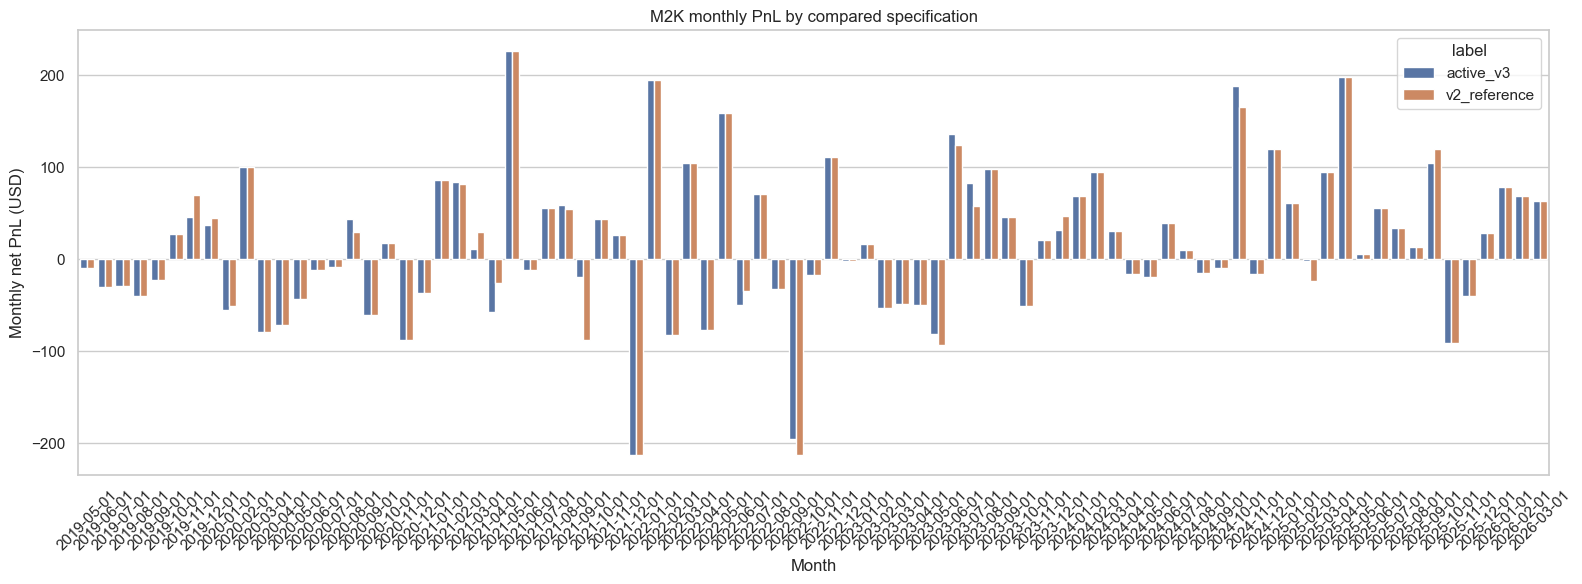

In [9]:
named_bundles = {
    "active_v3": active_bundle,
    "v2_reference": v2_reference_bundle,
}


exit_reason_rows = []
direction_rows = []
monthly_rows = []
for label, bundle in named_bundles.items():
    trades = bundle["trades"].copy()
    if not trades.empty:
        exit_summary = (
            trades.groupby("exit_reason", as_index=False)
            .agg(
                n_trades=("exit_reason", "count"),
                net_pnl_usd=("net_pnl_usd", "sum"),
                avg_pnl_usd=("net_pnl_usd", "mean"),
            )
        )
        exit_summary["label"] = label
        exit_reason_rows.append(exit_summary)

        direction_summary = (
            trades.groupby("direction", as_index=False)
            .agg(
                n_trades=("direction", "count"),
                net_pnl_usd=("net_pnl_usd", "sum"),
                avg_pnl_usd=("net_pnl_usd", "mean"),
            )
        )
        direction_summary["label"] = label
        direction_rows.append(direction_summary)

    daily = bundle["daily_results"].copy()
    daily["month"] = pd.to_datetime(daily["session_date"]).dt.to_period("M").dt.to_timestamp()
    monthly = daily.groupby("month", as_index=False)["daily_pnl_usd"].sum()
    monthly["label"] = label
    monthly_rows.append(monthly)

if exit_reason_rows:
    exit_reason_summary = rounded_view(pd.concat(exit_reason_rows, ignore_index=True), digits=2)
    display(Markdown("### Exit reasons"))
    display(exit_reason_summary)

if direction_rows:
    direction_summary = rounded_view(pd.concat(direction_rows, ignore_index=True), digits=2)
    display(Markdown("### Direction mix"))
    display(direction_summary)

monthly_summary = pd.concat(monthly_rows, ignore_index=True)
plt.figure(figsize=(16, 6))
sns.barplot(data=monthly_summary, x="month", y="daily_pnl_usd", hue="label")
plt.title(f"{SYMBOL} monthly PnL by compared specification")
plt.ylabel("Monthly net PnL (USD)")
plt.xlabel("Month")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 7. Conclusion client

Le bon usage de ce notebook:

- valider la spec gelee telle quelle,
- verifier ou elle se place face a V2 et au benchmark,
- documenter la lisibilite du voisinage de robustesse,
- modifier le premier bloc seulement si on veut tester un autre point **de la meme grille V3 compacte**.


In [10]:
conclusion_lines = [
    "### Verdict client net",
    f"- Spec gelee par defaut: `{FROZEN_VARIANT_NAME}`.",
    f"- Si le notebook reste sur la spec gelee, la recommandation exportee pour {SYMBOL} tient toujours.",
    f"- La comparaison V2 rechargee ici reste `{FROZEN_V2_REFERENCE_VARIANT_NAME}`.",
    f"- OOS active vs V2: Sharpe `{fmt_float(active_metrics.loc['oos', 'sharpe'])}` vs `{fmt_float(v2_reference_metrics.loc['oos', 'sharpe'])}`, Net PnL `{fmt_money(active_metrics.loc['oos', 'net_pnl'])}` vs `{fmt_money(v2_reference_metrics.loc['oos', 'net_pnl'])}`.",
    f"- Le benchmark buy & hold reste un repere de marche, pas de baseline metier principal.",
    f"- Si tu modifies les knobs du premier bloc et qu un variant correspondant existe dans l export V3, le notebook se rejoue proprement sans elargir la campagne.",
]

display(Markdown("\n".join(conclusion_lines)))


### Verdict client net
- Spec gelee par defaut: `dynamic_exit_atr_target_1p0_ts4_vq0p95_bf0p5_ra1p2`.
- Si le notebook reste sur la spec gelee, la recommandation exportee pour M2K tient toujours.
- La comparaison V2 rechargee ici reste `dynamic_exit_atr_target_1p0_ts3_vq0p95_bf0p5_ra1p2`.
- OOS active vs V2: Sharpe `1.567` vs `1.515`, Net PnL `986.7 USD` vs `956.7 USD`.
- Le benchmark buy & hold reste un repere de marche, pas de baseline metier principal.
- Si tu modifies les knobs du premier bloc et qu un variant correspondant existe dans l export V3, le notebook se rejoue proprement sans elargir la campagne.